Step 1. Dataset creation

In [1]:
import numpy as np

X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])

y = np.array([[0],
              [1],
              [1],
              [0]])

Keras implementation

In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

Step 2:

In [4]:
model = Sequential([
    Dense(2, input_dim=2, activation='tanh'),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Step 3:

In [5]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

Step 4:

In [8]:
model.fit(X, y, epochs=1000, verbose=0)

step 5:

In [9]:
predictions = model.predict(X)
print("Keras Predictions:")
print(np.round(predictions))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Keras Predictions:
[[0.]
 [1.]
 [1.]
 [0.]]


With epochs=100

In [10]:
model.fit(X, y, epochs=100, verbose=0)

In [11]:
predictions = model.predict(X)
print("Keras Predictions:")
print(np.round(predictions))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Keras Predictions:
[[0.]
 [1.]
 [1.]
 [0.]]


Using Tanh

In [53]:
model_tanh = Sequential([
    Dense(2, input_dim=2, activation='tanh'),
    Dense(1, activation='sigmoid')
])

model_tanh.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_tanh.fit(X, y, epochs=1000, verbose=0)

print("Tanh Predictions:")
print(np.round(model_tanh.predict(X)))

Tanh Predictions:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
[[0.]
 [1.]
 [1.]
 [0.]]


Changing hidden neurons to 1

In [47]:
model_tanh = Sequential([
    Dense(1, input_dim=2, activation='tanh'),
    Dense(1, activation='sigmoid')
])

model_tanh.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_tanh.fit(X, y, epochs=1000, verbose=0)

print("Tanh Predictions:")
print(np.round(model_tanh.predict(X)))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Tanh Predictions:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
[[0.]
 [1.]
 [1.]
 [1.]]


Using ReLU:

In [54]:
model_relu = Sequential([
    Dense(2, input_dim=2, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_relu.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_relu.fit(X, y, epochs=1000, verbose=0)

print("ReLU Predictions:")
print(np.round(model_relu.predict(X)))

ReLU Predictions:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
[[0.]
 [1.]
 [0.]
 [0.]]


Plotting decision boundary:

In [31]:
import numpy as np
import matplotlib.pyplot as plt

In [32]:
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200),
                     np.linspace(-0.5, 1.5, 200))

grid = np.c_[xx.ravel(), yy.ravel()]

In [34]:
grid_torch = torch.tensor(grid, dtype=torch.float32)
with torch.no_grad():
    Z = model(grid_torch).numpy()
Z = Z.reshape(xx.shape)

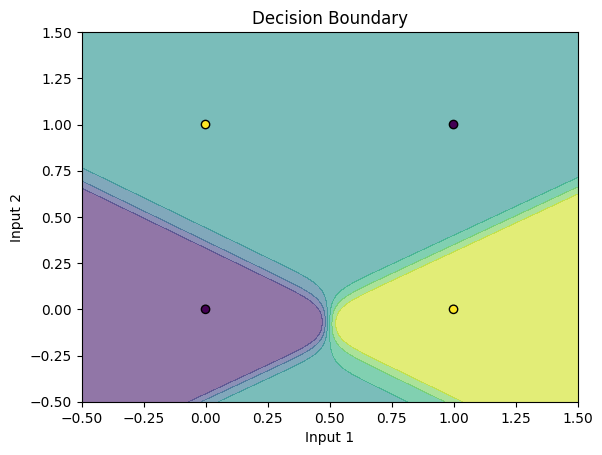

In [35]:
plt.contourf(xx, yy, Z, alpha=0.6)
plt.scatter(X[:,0], X[:,1], c=y.flatten(), edgecolors='k')
plt.xlabel("Input 1")
plt.ylabel("Input 2")
plt.title("Decision Boundary")
plt.show()

Decision boundary is non-linear and clearly separates (0,1) and (1,0) from (0,0) and (1,1)

Training curve:

In [39]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(2, input_dim=2, activation='tanh'),
    Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer='adam'
)

history = model.fit(X, y, epochs=1000, verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


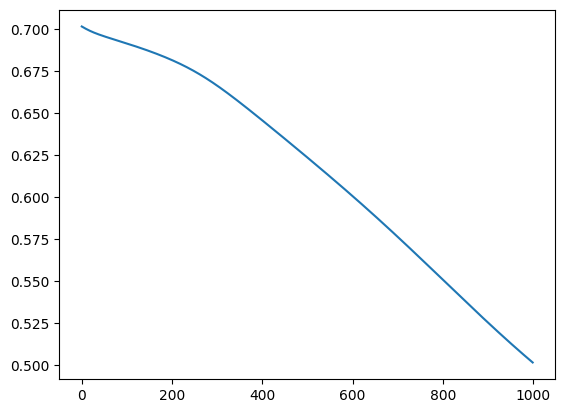

In [40]:
plt.plot(history.history['loss'])
plt.show()

PyTorch implemenataion

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim

In [13]:
X_torch = torch.tensor(X, dtype=torch.float32)
y_torch = torch.tensor(y, dtype=torch.float32)

Step 2:

In [14]:
class XORNet(nn.Module):
    def __init__(self):
        super(XORNet, self).__init__()
        self.hidden = nn.Linear(2, 2)
        self.output = nn.Linear(2, 1)

    def forward(self, x):
        x = torch.tanh(self.hidden(x))
        x = torch.sigmoid(self.output(x))
        return x

model = XORNet()

Step 3:

In [15]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

Step 4:

In [16]:
for epoch in range(1000):
    optimizer.zero_grad()
    output = model(X_torch)
    loss = criterion(output, y_torch)
    loss.backward()
    optimizer.step()

Step 5:

In [17]:
with torch.no_grad():
    predictions = model(X_torch)
    print("PyTorch Predictions:")
    print(torch.round(predictions))

PyTorch Predictions:
tensor([[0.],
        [0.],
        [1.],
        [0.]])


For lr 0.05

In [19]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.05)

In [20]:
for epoch in range(1000):
    optimizer.zero_grad()
    output = model(X_torch)
    loss = criterion(output, y_torch)
    loss.backward()
    optimizer.step()

In [21]:
with torch.no_grad():
    predictions = model(X_torch)
    print("PyTorch Predictions:")
    print(torch.round(predictions))

PyTorch Predictions:
tensor([[0.],
        [0.],
        [1.],
        [0.]])


Model fails to converge leading to incorrect results.

TenserFlow implementation

In [22]:
import tensorflow as tf

In [23]:
W1 = tf.Variable(tf.random.normal([2, 2]))
b1 = tf.Variable(tf.zeros([2]))

W2 = tf.Variable(tf.random.normal([2, 1]))
b2 = tf.Variable(tf.zeros([1]))

In [44]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)

In [26]:
for epoch in range(1000):
    with tf.GradientTape() as tape:
        X_float = tf.cast(X, dtype=tf.float32)
        y_float = tf.cast(y, dtype=tf.float32)

        hidden = tf.tanh(tf.matmul(X_float, W1) + b1)
        output = tf.sigmoid(tf.matmul(hidden, W2) + b2)
        loss = tf.reduce_mean(tf.keras.losses.binary_crossentropy(y_float, output))

    gradients = tape.gradient(loss, [W1, b1, W2, b2])
    optimizer.apply_gradients(zip(gradients, [W1, b1, W2, b2]))

In [49]:
predictions = tf.round(output)
print("TensorFlow Low-Level Predictions:")
print(predictions.numpy())

TensorFlow Low-Level Predictions:
[[0.]
 [0.]
 [1.]
 [0.]]


Changing Learning rate:

In [48]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.1)

In [50]:
for epoch in range(1000):
    with tf.GradientTape() as tape:
        X_float = tf.cast(X, dtype=tf.float32)
        y_float = tf.cast(y, dtype=tf.float32)

        hidden = tf.tanh(tf.matmul(X_float, W1) + b1)
        output = tf.sigmoid(tf.matmul(hidden, W2) + b2)
        loss = tf.reduce_mean(tf.keras.losses.binary_crossentropy(y_float, output))

    gradients = tape.gradient(loss, [W1, b1, W2, b2])
    optimizer.apply_gradients(zip(gradients, [W1, b1, W2, b2]))

In [51]:
predictions = tf.round(output)
print("TensorFlow Low-Level Predictions:")
print(predictions.numpy())

TensorFlow Low-Level Predictions:
[[0.]
 [0.]
 [1.]
 [0.]]


High learning rate caused larger weights updates and model did not converged leading to incorrect XOR results.

1. Learining rate

Moderate learing rate is ideal for XOR as the loss value descreased during training and model converged within 500-1000 epochs.

With learing rates 0.05 and 0.1, incorrect results were produced.

2. Activation function

Tanh correctly classified all four XOR inputs and it performed better then ReLU due to its range being -1 to 1.

ReLU failed as it misclassified one input due to dead neuron problem

3. Hidden Layers

A simple MLP with one hidden layer and two neurons was sufficient for XOR.

Only one hidden neuron, we got incorrect output.

4. Epochs number

When the number of epochs was reduced to 100, the model was still able to correctly learn the XOR function.

5. Overall across libraries

All produced correct XOR predictions. Keras had simplest training process.